<h2>Análisis discriminante lineal (LDA) y análisis discriminante cuadrático (QDA)</h2>

<a href='https://www.cienciadedatos.net/documentos/28_linear_discriminant_analysis_lda_y_quadratic_discriminant_analysis_qda'>Referencia. Cienciadedatos.net</a>

In [9]:
load('.RData')

In [94]:
library(ggplot2)
library(tidyverse)
library(ggpubr)
library(scatterplot3d)
library(reshape2)
library(MASS)
library(caret)
library(klaR)

In [7]:
#Usamos el dataset sin datos NA
df <- na.omit(df_penguins)
head(df)

species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>,<int>
Adelie,Torgersen,39.1,18.7,181,3750,male,2007
Adelie,Torgersen,39.5,17.4,186,3800,female,2007
Adelie,Torgersen,40.3,18.0,195,3250,female,2007
Adelie,Torgersen,36.7,19.3,193,3450,female,2007
Adelie,Torgersen,39.3,20.6,190,3650,male,2007
Adelie,Torgersen,38.9,17.8,181,3625,female,2007


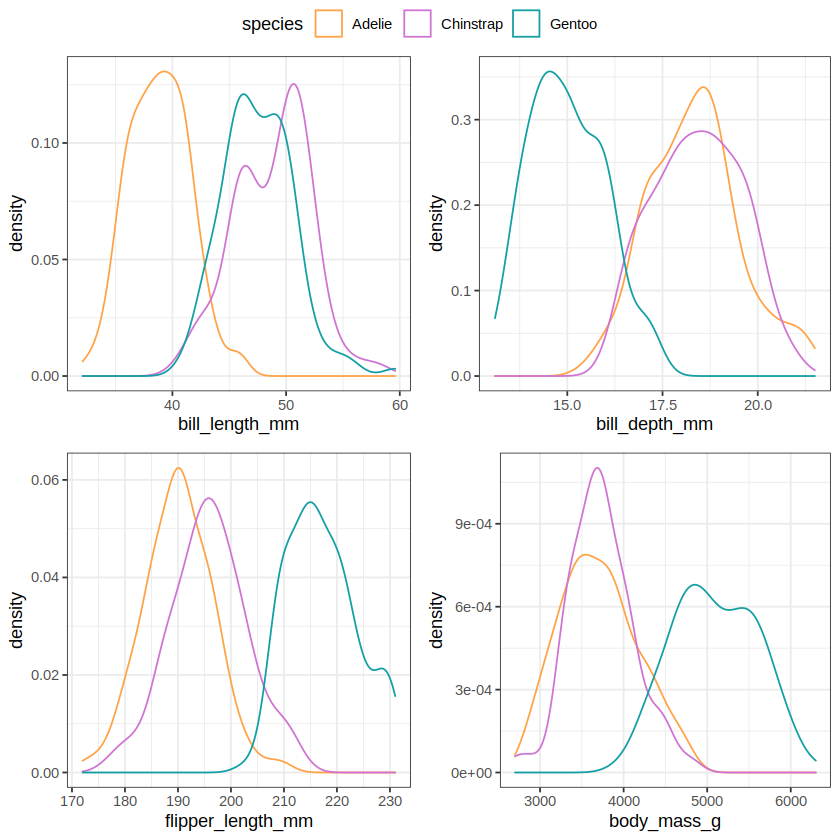

In [63]:
p1 <- ggplot(df, 
        aes(x = bill_length_mm)) +
        geom_density(aes(colour = species)) +
        scale_color_manual(values = penguins_color)+
        theme_bw()
p2 <- ggplot(df, 
        aes(x = bill_depth_mm)) +
        geom_density(aes(colour = species)) +
        scale_color_manual(values = penguins_color)+
        theme_bw()
p3 <- ggplot(df, 
        aes(x = flipper_length_mm)) +
        geom_density(aes(colour = species)) +
        scale_color_manual(values = penguins_color)+
        theme_bw()
p4 <- ggplot(df, 
        aes(x = body_mass_g)) +
        geom_density(aes(colour = species)) +
        scale_color_manual(values = penguins_color)+
        theme_bw()

ggarrange(p1, p2, p3, p4, nrow = 2, ncol =2, common.legend = TRUE, legend="top")

<h4>Prior probabilities</h4>
Como no se dispone de información sobre la abundancia relativa de las especies a nivel poblacional, se considera como probabilidad previa de cada especie el número de observaciones de la especie entre el número de observaciones totales.
Adelie = 0.44; Chinsrap = 0.2, Gentoo = 0.36

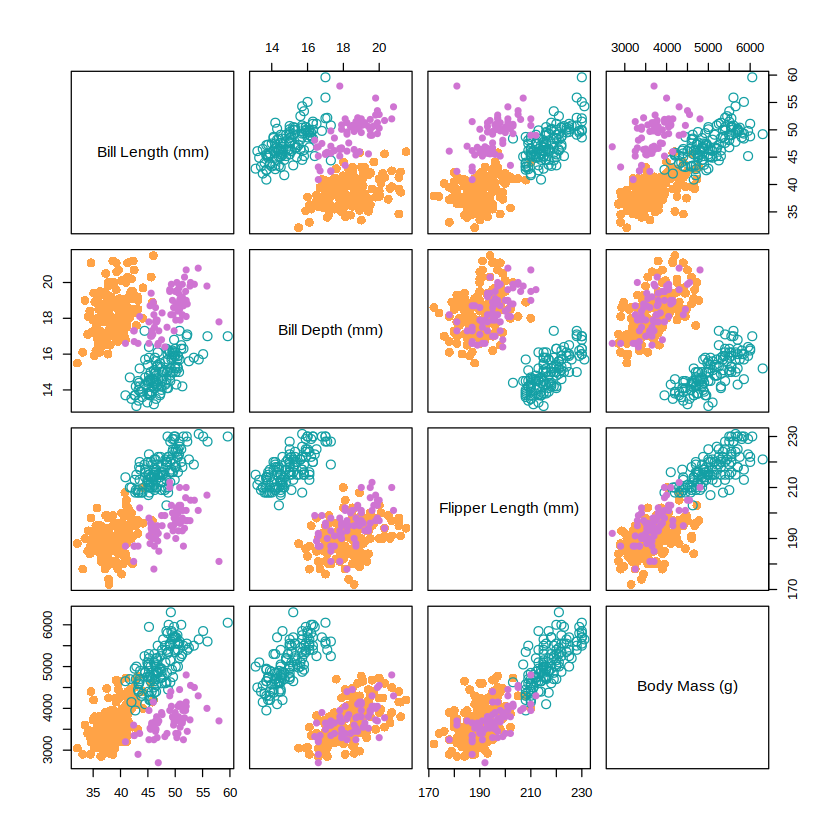

In [26]:
pairs(df_penguins[,3:6], 
      cex=1.5, 
      labels = c('Bill Length (mm)', 'Bill Depth (mm)', 'Flipper Length (mm)', 'Body Mass (g)'), 
      pch=c(16, 20, 21)[df_penguins$species], 
      col = penguins_color[df_penguins$species])

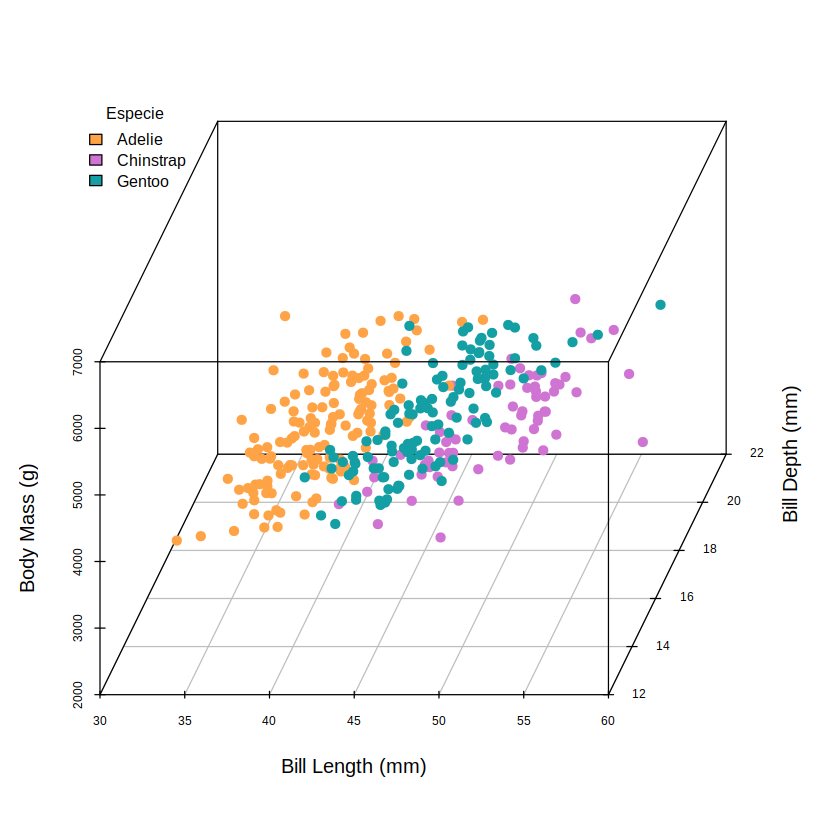

In [105]:
scatterplot3d(df$bill_length_mm, df$bill_depth_mm,  df$body_mass_g, 
              color = penguins_color[df$species], pch = 19,
              grid = TRUE, xlab = "Bill Length (mm)", ylab = "Bill Depth (mm)",
              zlab = "Body Mass (g)", angle = 65, cex.axis = 0.6)
legend("topleft",
       bty = "n", cex = 0.8,
       title = "Especie", c('Adelie', 'Chinstrap', 'Gentoo'), fill = penguins_color)

In [74]:
fit_control <- trainControl(## 10-fold CV
                           method = "repeatedcv",
                           number = 10,
                           ## repeated ten times
                           repeats = 10,
                           classProbs=TRUE)

In [77]:
set.seed(55)
index <- createDataPartition(df$species, p = 0.75, list = FALSE)
train_data <- df[index, ]
test_data <- df[-index, ]
sprintf("The trainining set contains %d rows", nrow(train_data))
sprintf("The test set contains %d rows", nrow(test_data))

[1] "The trainining set contains 251 rows"

[1] "The test set contains 82 rows"

In [78]:
table(train_data$species)

train_balanced <- upSample(x = train_data, y = train_data$species)
train_balanced = train_balanced[, !(colnames(train_balanced) %in% c("Class"))]

table(train_balanced$species)


   Adelie Chinstrap    Gentoo 
      110        51        90 


   Adelie Chinstrap    Gentoo 
      110       110       110 

<h4>Modelo LDA</h4>

In [99]:
#lda model usando paquete caret

lda_model <- train(species ~ bill_length_mm + bill_depth_mm + flipper_length_mm + body_mass_g, 
                data = train_balanced, method = 'lda', trControl = fit_control)
lda_model

Linear Discriminant Analysis 

330 samples
  4 predictor
  3 classes: 'Adelie', 'Chinstrap', 'Gentoo' 

No pre-processing
Resampling: Cross-Validated (10 fold, repeated 10 times) 
Summary of sample sizes: 297, 297, 297, 297, 297, 297, ... 
Resampling results:

  Accuracy   Kappa    
  0.9909091  0.9863636


In [85]:
lda_preds <- predict(lda_model, newdata = test_data)
confusionMatrix(data = lda_preds, test_data$species)

Confusion Matrix and Statistics

           Reference
Prediction  Adelie Chinstrap Gentoo
  Adelie        36         1      0
  Chinstrap      0        16      0
  Gentoo         0         0     29

Overall Statistics
                                          
               Accuracy : 0.9878          
                 95% CI : (0.9339, 0.9997)
    No Information Rate : 0.439           
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.9808          
                                          
 Mcnemar's Test P-Value : NA              

Statistics by Class:

                     Class: Adelie Class: Chinstrap Class: Gentoo
Sensitivity                 1.0000           0.9412        1.0000
Specificity                 0.9783           1.0000        1.0000
Pos Pred Value              0.9730           1.0000        1.0000
Neg Pred Value              1.0000           0.9848        1.0000
Prevalence                  0.4390        

In [112]:
paste('training error = ', round(mean(test_data$species != lda_preds) * 100, 2), '%')

[1] "training error =  1.22 %"

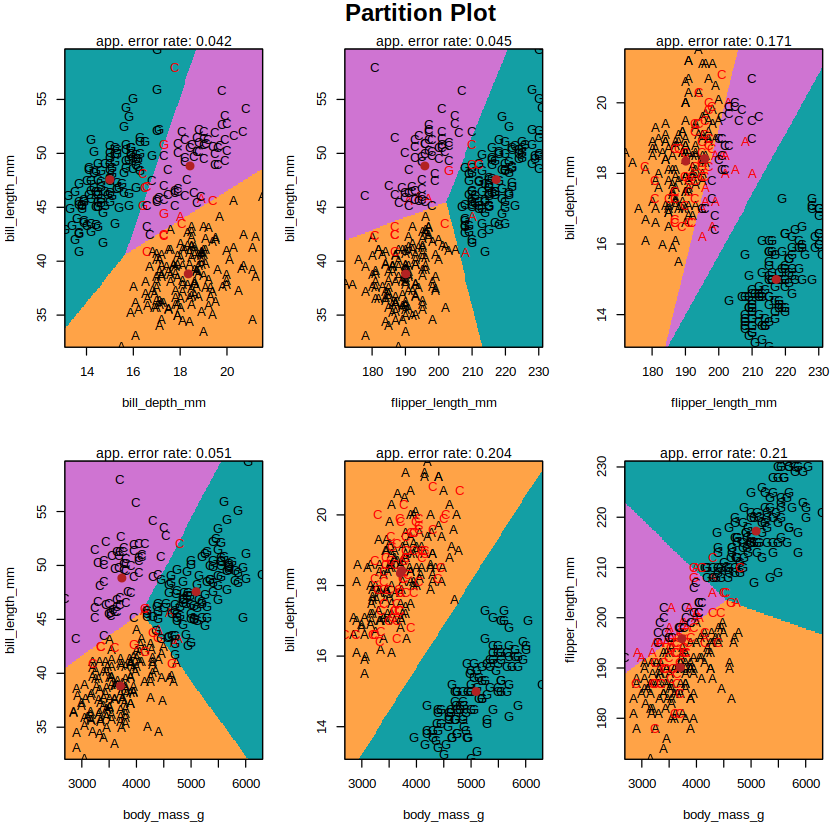

In [113]:
partimat(species ~ bill_length_mm + bill_depth_mm + flipper_length_mm + body_mass_g,
         data = df, method = "lda", prec = 200,
         image.colors = penguins_color,
         col.mean = "firebrick")

<h4>Modelo QDA</h4>

In [110]:
#Qda model usando paquete caret

qda_model <- train(species ~ bill_length_mm + bill_depth_mm + flipper_length_mm + body_mass_g, 
                data = train_balanced, method = 'qda', trControl = fit_control)
qda_model

Quadratic Discriminant Analysis 

330 samples
  4 predictor
  3 classes: 'Adelie', 'Chinstrap', 'Gentoo' 

No pre-processing
Resampling: Cross-Validated (10 fold, repeated 10 times) 
Summary of sample sizes: 297, 297, 297, 297, 297, 297, ... 
Resampling results:

  Accuracy  Kappa
  0.99      0.985


In [114]:
qda_preds <- predict(qda_model, newdata = test_data)
confusionMatrix(data = qda_preds, test_data$species)
paste('training error = ', round(mean(test_data$species != qda_preds) * 100, 2), '%')

Confusion Matrix and Statistics

           Reference
Prediction  Adelie Chinstrap Gentoo
  Adelie        36         1      0
  Chinstrap      0        16      0
  Gentoo         0         0     29

Overall Statistics
                                          
               Accuracy : 0.9878          
                 95% CI : (0.9339, 0.9997)
    No Information Rate : 0.439           
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.9808          
                                          
 Mcnemar's Test P-Value : NA              

Statistics by Class:

                     Class: Adelie Class: Chinstrap Class: Gentoo
Sensitivity                 1.0000           0.9412        1.0000
Specificity                 0.9783           1.0000        1.0000
Pos Pred Value              0.9730           1.0000        1.0000
Neg Pred Value              1.0000           0.9848        1.0000
Prevalence                  0.4390        

[1] "training error =  1.22 %"

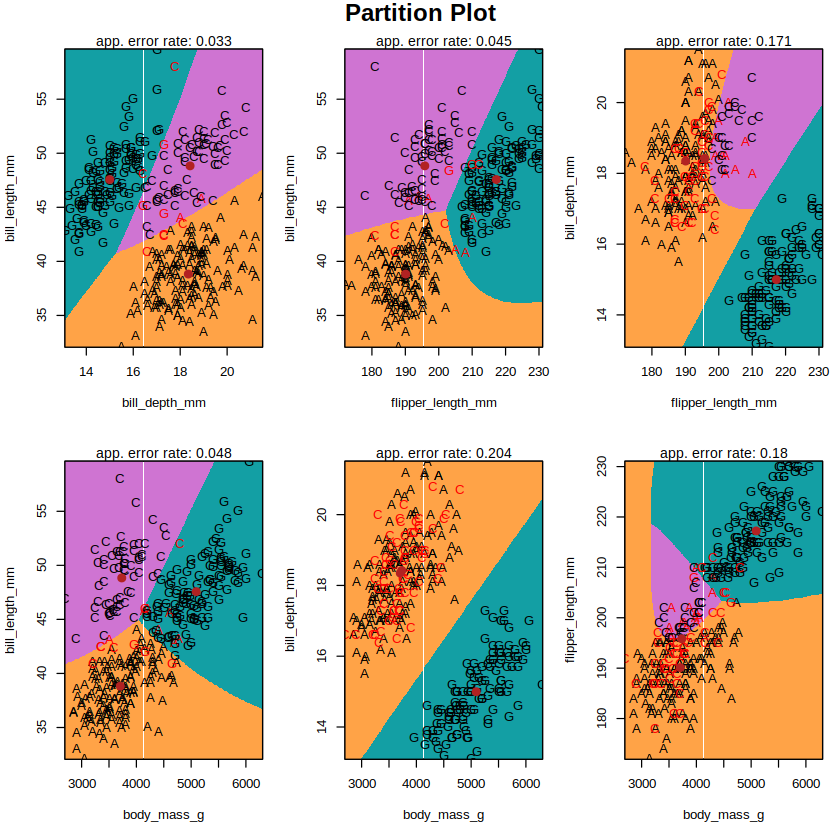

In [116]:
partimat(formula = species ~ bill_length_mm + bill_depth_mm + flipper_length_mm + body_mass_g,
         data = df, method = "qda", prec = 400,
         image.colors = penguins_color,
         col.mean = "firebrick")